# Trajectory Inference with Palantir

This tutorial uses pancreas endocrine development data to demonstrate Palantir pseudotime inference, branch inspection, gene-trend summaries, and a branch-aware pseudotime stream plot built with `ov.pl.branch_streamplot`.

## Method background

Following the [Palantir documentation](https://palantir.readthedocs.io/en/latest/) and the original [Nature Biotechnology paper](https://www.nature.com/articles/s41587-019-0068-4), Palantir models differentiation as a stochastic process on a diffusion manifold.

Its core logic is:

- compute diffusion components from a denoised low-dimensional representation
- choose an early/root cell and order cells along pseudotime
- identify terminal states and estimate branch-specific fate probabilities
- summarize gene expression trends along pseudotime and across terminal branches

This makes Palantir especially useful when we care about both a shared developmental trunk and gradual commitment toward multiple endpoints.

## Why use the pancreas dataset here?

Pancreatic endocrine development is a compact teaching example for Palantir because it contains a clear progenitor-to-endocrine progression and multiple endocrine fates. That makes it easy to inspect pseudotime, branch probabilities, and branch-aware gene trends in one tutorial.

## Preprocess data

As an example, we apply trajectory inference to pancreas development.


In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov
ov.plot_set(font_path='Arial')

%load_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata=ov.datasets.pancreatic_endocrinogenesis()

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


In [3]:
adata=ov.pp.preprocess(adata,mode='shiftlog|pearson',n_HVGs=3000,)
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
ov.pp.scale(adata)
ov.pp.pca(adata,layer='scaled',n_pcs=50)

🔍 [2026-04-25 11:07:29] Running preprocessing in 'cpu' mode...
Begin robust gene identification


    After filtration, 17750/27998 genes are kept.
    Among 17750 genes, 16426 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,696 cells × 16,426 genes
   ✓ Runtime: 0.11s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 3,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 3,000 highly variable genes out of 16,426 total (18.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.62 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.2965s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 3696x3000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (3696, 3000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (4.29s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 4.2928s                                                 │
│  Shape:    3,696 x 3,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ scaled|original|X_pca (array, 3696x50)               │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


Let us inspect the contribution of single PCs to the total variance in the data. This gives us information about how many PCs we should consider in order to compute the neighborhood relations of cells. In our experience, often a rough estimate of the number of PCs does fine.

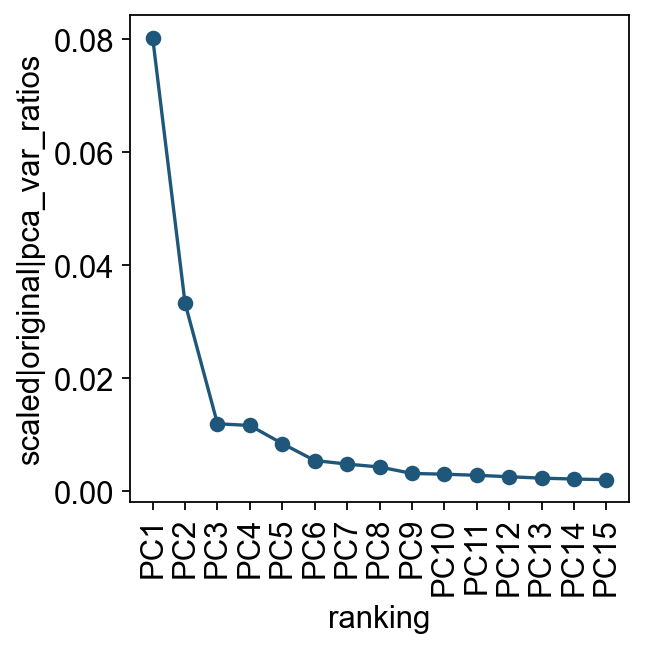

In [4]:
ov.utils.plot_pca_variance_ratio(adata, n_pcs=15)

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


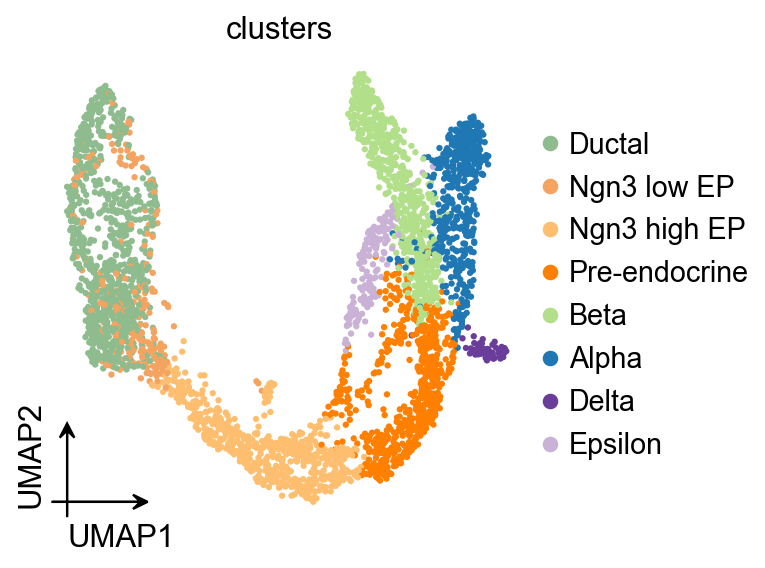

In [5]:
ov.pl.umap(
    adata,
    color='clusters'
)

## Palantir

Palantir can be run by specifying an approxiate early cell.

Palantir can automatically determine the terminal states as well. In this dataset, we know the terminal states and we will set them using the terminal_states parameter

Here, we used `ov.single.TrajInfer` to construct a Trajectory Inference object.

In [6]:
Traj=ov.single.TrajInfer(
    adata,
    basis='X_umap',
    groupby='clusters',
    use_rep='scaled|original|X_pca',
    n_comps=50
)
Traj.set_origin_cells('Ductal')
Traj.set_terminal_cells(["Alpha","Beta","Delta","Epsilon"])

In [7]:
Traj.inference(method='palantir',num_waypoints=500)

**finished identifying marker genes by COSG**
Sampling and flocking waypoints...
Time for determining waypoints: 0.00039926369984944664 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


Time for shortest paths: 0.12345218261082967 minutes
Iteratively refining the pseudotime...


Correlation at iteration 1: 0.9998


Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


Palantir results can be visualized on the tSNE or UMAP using the plot_palantir_results function

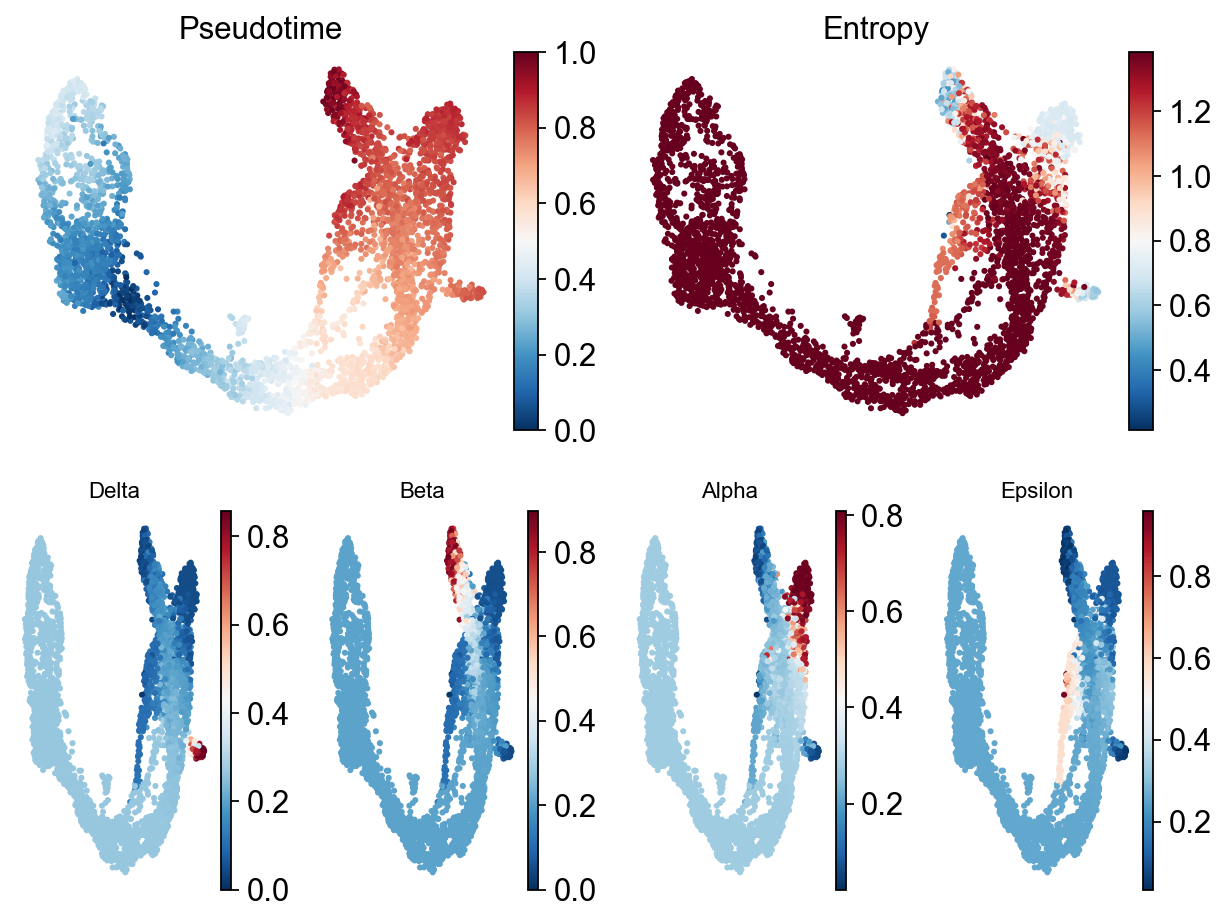

In [8]:
Traj.palantir_plot_pseudotime(
    embedding_basis='X_umap',
    cmap='RdBu_r',
    s=3,
    n_cols=4,
    figsize=(8, 6),
)

Once the cells are selected, it's often helpful to visualize the selection on the pseudotime trajectory to ensure we've isolated the correct cells for our specific trend. We can do this using the plot_branch_selection function:

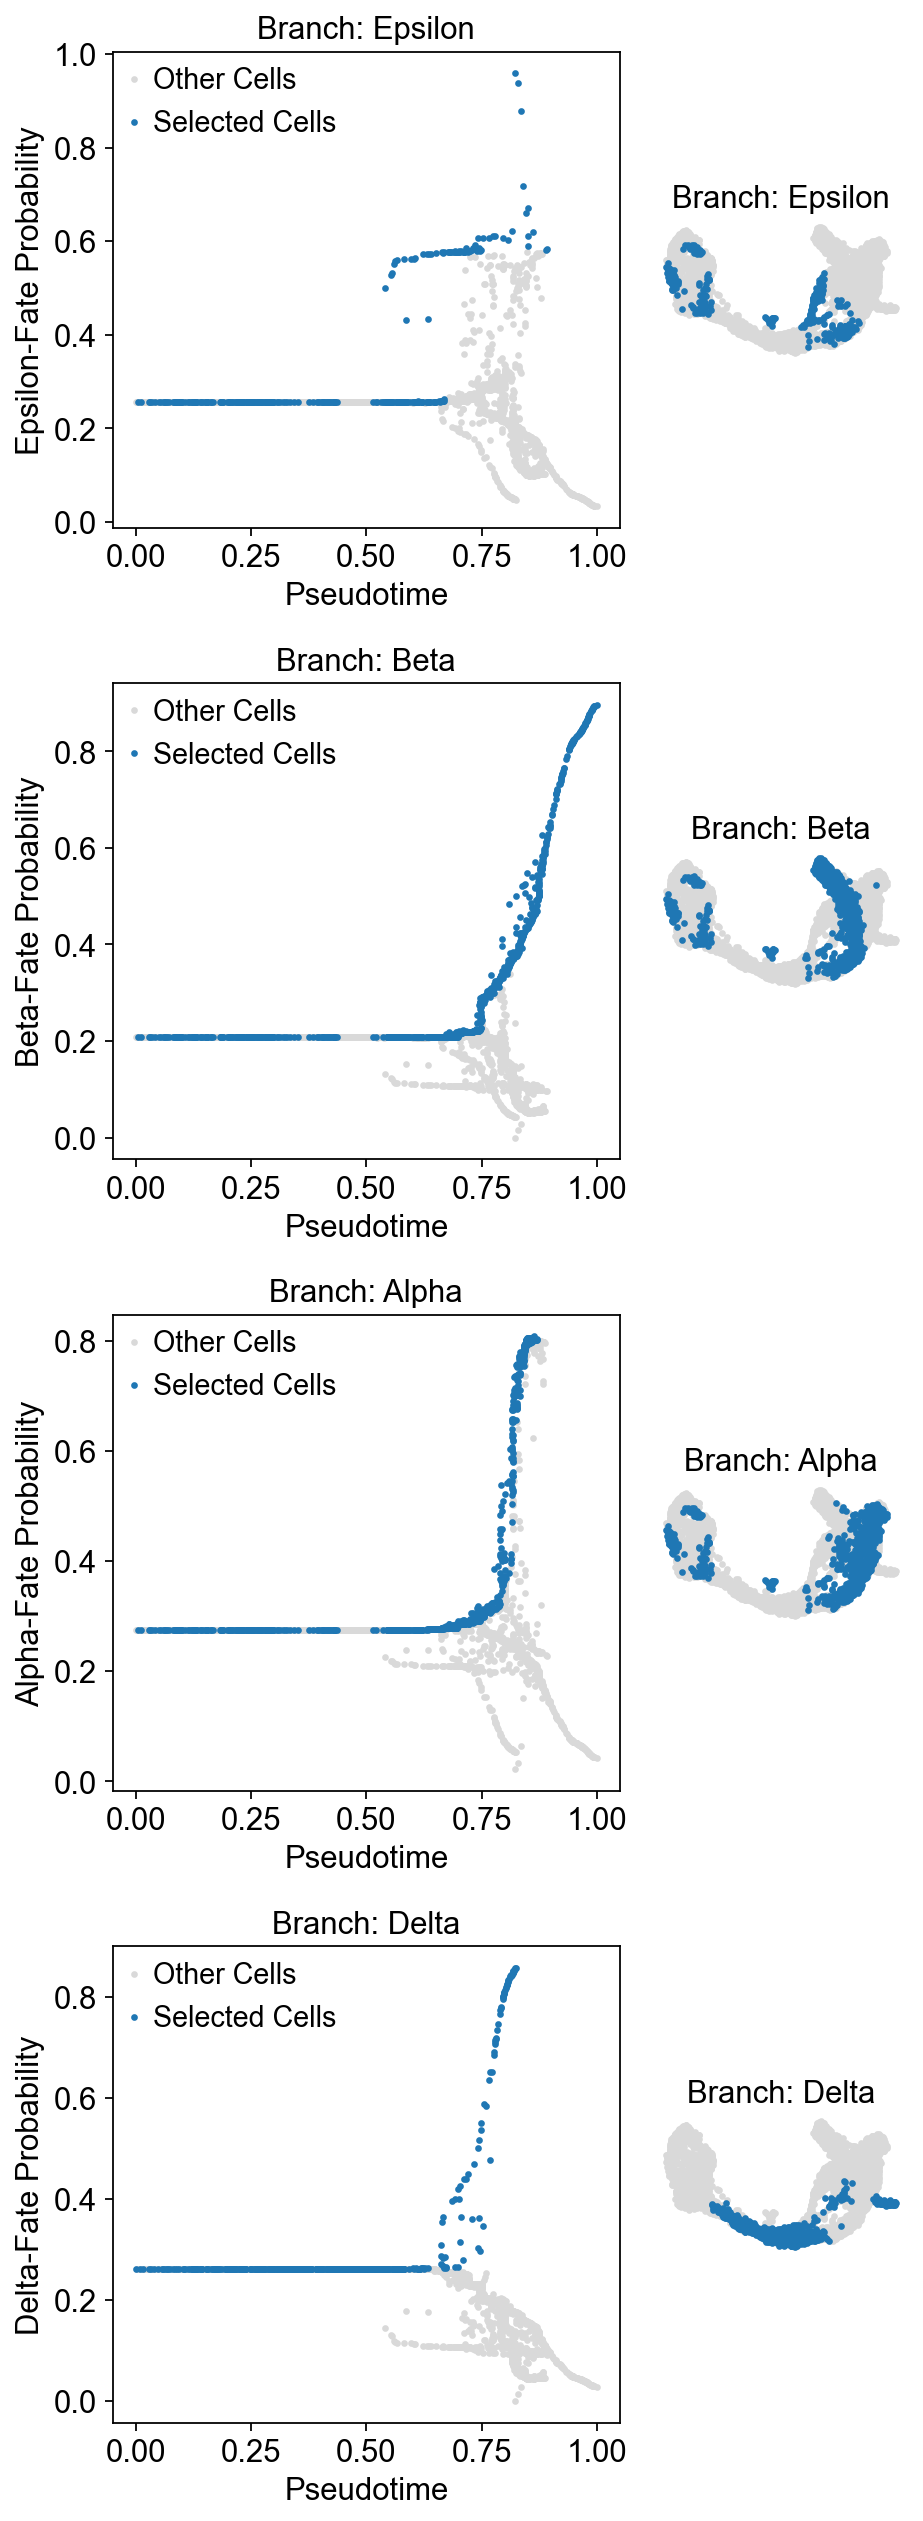

In [9]:
Traj.palantir_cal_branch(
    eps=0,
    plot_kwargs={
        'figsize': (6, 4),
        'selected_color': '#1f77b4',
        'deselected_color': '#d9d9d9',
        's': 4,
    },
)

[2026-04-25 11:07:59,207] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (805) and rank = 1.0.


[2026-04-25 11:07:59,207] [INFO    ] Using covariance function Matern52(ls=1.262711524963379).


[2026-04-25 11:07:59,220] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).


[2026-04-25 11:08:00,272] [INFO    ] Sigma interpreted as element-wise standard deviation.


<Axes: title={'center': 'Branch: Alpha'}, xlabel='UMAP1', ylabel='UMAP2'>

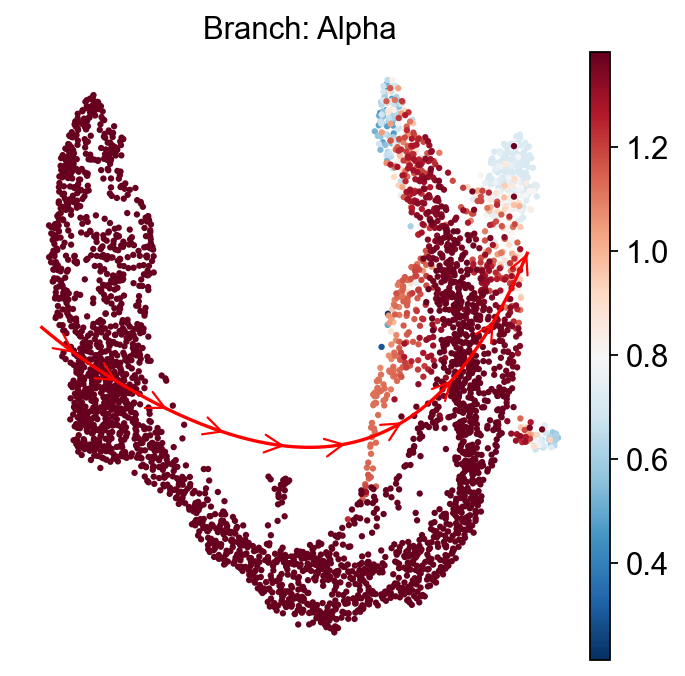

In [10]:
ov.external.palantir.plot.plot_trajectory(
    adata,
    "Alpha",
    cell_color="palantir_entropy",
    n_arrows=10,
    color="red",
    scanpy_kwargs=dict(cmap="RdBu_r"),
)

## Branch-aware pseudotime stream plot

After computing `palantir_pseudotime`, we can summarize cluster occupancy along pseudotime with KDE-smoothed ribbons and lay them out on a simple branch skeleton. This gives a compact trajectory-level overview that is useful for publication-style pseudotime figures.


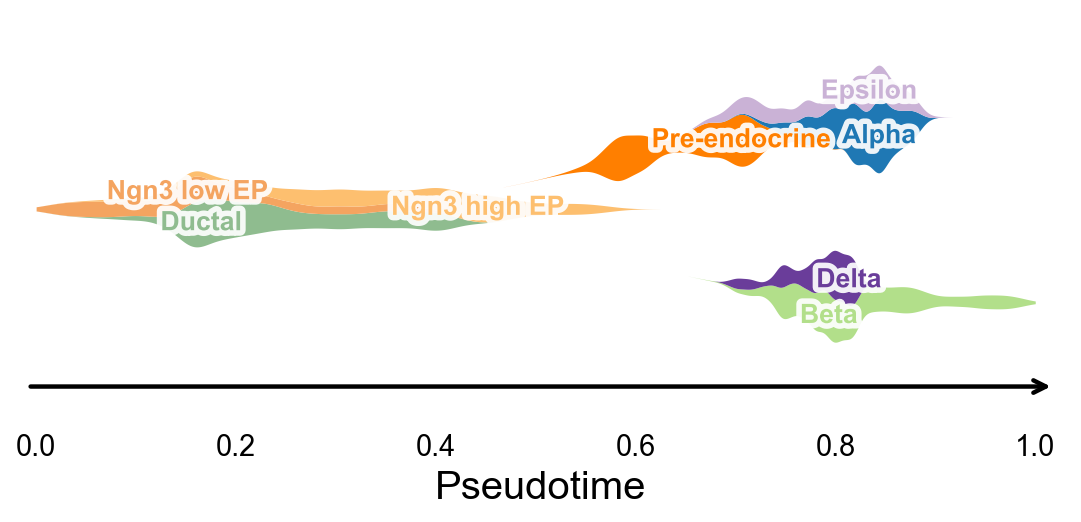

In [11]:
fig, ax = ov.pl.branch_streamplot(
    adata,
    group_key='clusters',
    pseudotime_key='palantir_pseudotime',
    show=False,
)
plt.show()

Palantir uses Mellon Function Estimator to determine the gene expression trends along different lineages. The marker trends can be determined using the following snippet. This computes the trends for all lineages. A subset of lineages can be used using the lineages parameter.

In [12]:
adata.layers['lognorm'] = adata.X.copy()
# MAGIC currently conflicts with the NumPy version in the dev environment,
# so we keep a stable smoothed-expression placeholder layer for downstream trends/heatmaps.
adata.layers['MAGIC_imputed_data'] = adata.layers['lognorm'].copy()

In [13]:
gene_trends = Traj.palantir_cal_gene_trends(
    layers="MAGIC_imputed_data",
)

Delta
[2026-04-25 11:08:01,250] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (624) and rank = 1.0.


[2026-04-25 11:08:01,250] [INFO    ] Using covariance function Matern52(ls=1.0).


[2026-04-25 11:08:02,158] [INFO    ] Sigma interpreted as element-wise standard deviation.


Beta
[2026-04-25 11:08:02,438] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (939) and rank = 1.0.


[2026-04-25 11:08:02,438] [INFO    ] Using covariance function Matern52(ls=1.0).


...

[2026-04-25 11:08:02,945] [INFO    ] Using covariance function Matern52(ls=1.0).


[2026-04-25 11:08:03,316] [INFO    ] Sigma interpreted as element-wise standard deviation.


Epsilon
[2026-04-25 11:08:03,426] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (324) and rank = 1.0.


[2026-04-25 11:08:03,426] [INFO    ] Using covariance function Matern52(ls=1.0).


[2026-04-25 11:08:03,810] [INFO    ] Sigma interpreted as element-wise standard deviation.



🔍 Dynamic feature analysis:
   Views: 4 | Features: 2
   Pseudotime: palantir_pseudotime
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600

🔍 Dynamic trend plotting:
   Features: 2 | Groups: 4
   compare_features=False | compare_groups=True


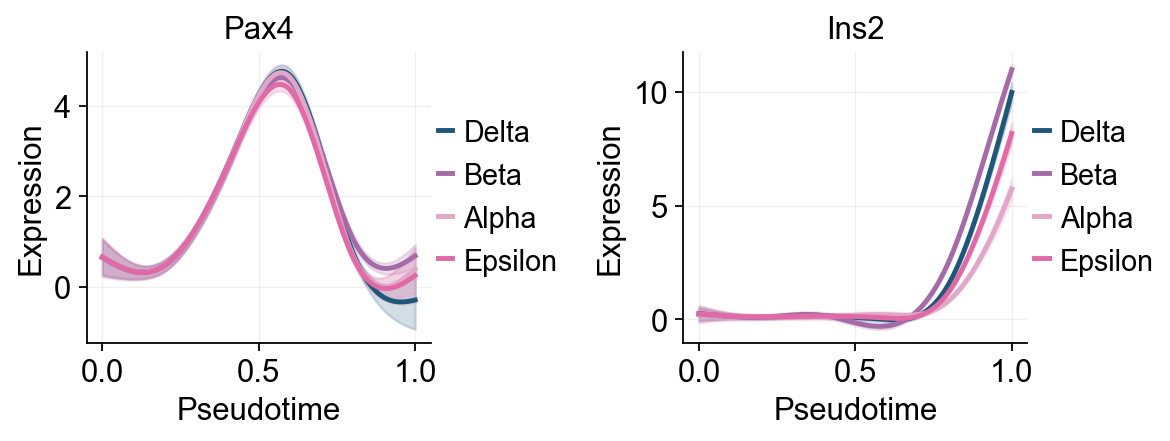

✅ Dynamic trend plotting completed!


In [14]:
Traj.palantir_plot_gene_trends(
    ['Pax4', 'Ins2'],
    layers='MAGIC_imputed_data',
    figsize=(4.5, 3),
    compare_groups=True,
    linewidth=2.2,
)
plt.show()


🔍 Dynamic feature analysis:
   Views: 2 | Features: 2
   Pseudotime: palantir_pseudotime
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/4 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 4/4
   ✓ Fitted rows: 800

🔍 Dynamic trend plotting:
   Features: 2 | Groups: 2
   compare_features=False | compare_groups=True


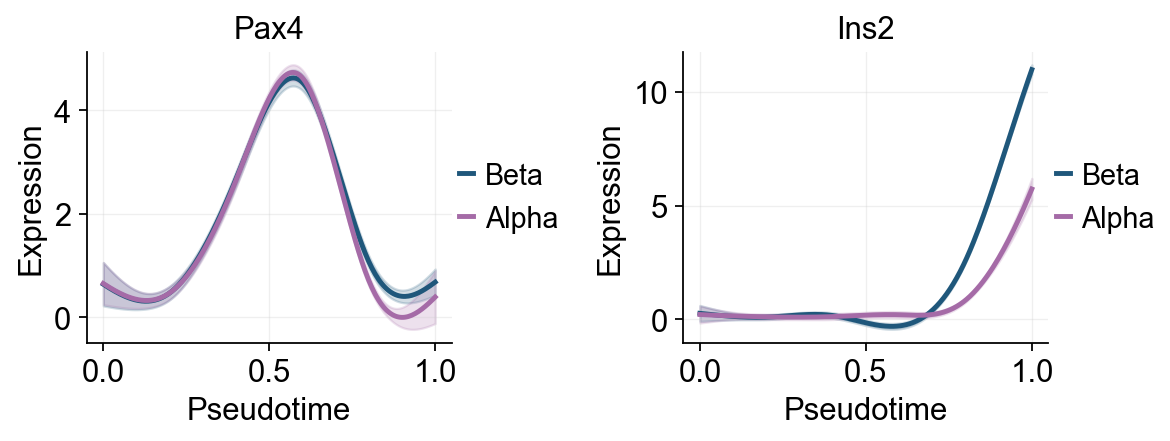

✅ Dynamic trend plotting completed!


In [15]:
Traj.palantir_plot_gene_trends(
    ['Pax4', 'Ins2'],
    lineages=['Beta', 'Alpha'],
    layers='MAGIC_imputed_data',
    figsize=(4.5, 3),
    compare_groups=True,
    linewidth=2.2,
)
plt.show()

## Fit GAM trends with `dynamic_features`

`ov.single.dynamic_features` fits GAM trends along Palantir pseudotime. The first panel summarizes global marker trends with raw points colored by clusters. A second Alpha/Beta panel compares late branch programs on the same pseudotime scale.

In [16]:
dynamic_feature_genes = ['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Sst', 'Hhex']

dyn_res = ov.single.dynamic_features(
    adata,
    genes=dynamic_feature_genes,
    pseudotime='palantir_pseudotime',
    layer='MAGIC_imputed_data',
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
    raw_obs_keys=['clusters'],
)

dyn_res.get_stats(successful_only=True).sort_values('peak_time')


🔍 Dynamic feature analysis:
   Views: 1 | Features: 10
   Pseudotime: palantir_pseudotime
   Stored raw obs keys: ['clusters']
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/10 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 10/10
   ✓ Fitted rows: 2000
   ✓ Raw observations stored: 36960


  dataset groupby_key group     gene  success error  n_cells  exp_ncells  \
1   adata        None  None  Neurog3     True  None     3696        1569   
9   adata        None  None     Hhex     True  None     3696        1300   
0   adata        None  None     Sox9     True  None     3696        1712   
5   adata        None  None     Pax4     True  None     3696        1087   
2   adata        None  None      Fev     True  None     3696        1449   
4   adata        None  None      Arx     True  None     3696         784   
8   adata        None  None      Sst     True  None     3696         253   
3   adata        None  None      Gcg     True  None     3696         827   
6   adata        None  None     Ins2     True  None     3696         496   
7   adata        None  None     Pdx1     True  None     3696        1974   

   peak_time  valley_time  min_pseudotime  max_pseudotime        r2  \
1   0.002513     0.891960             0.0             1.0  0.285898   
9   0.138191     0.98

### Single-line global trends

This view fits one global curve per gene and colors the raw cells by annotation. It is useful for separating the overall pseudotime trend from the cell-state composition that appears around that trend.




🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=False | compare_groups=False


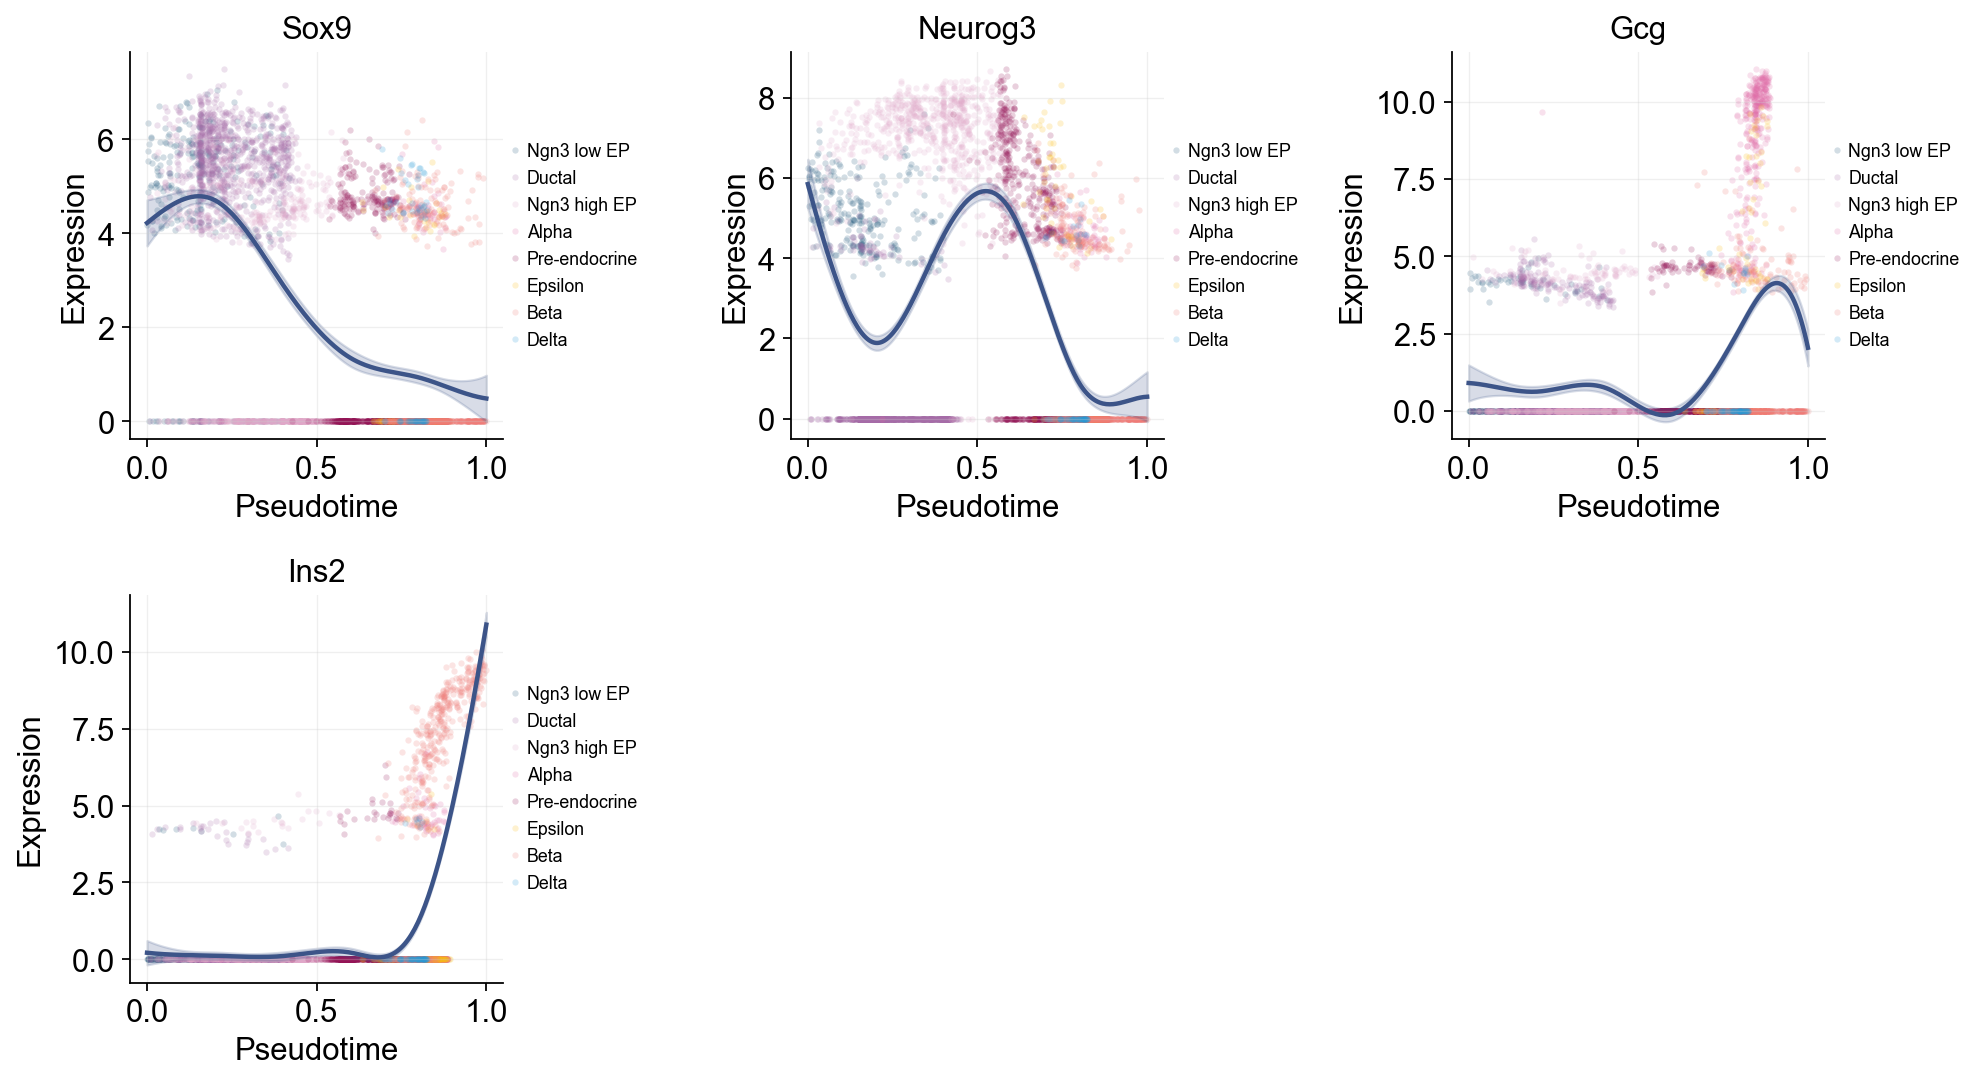

✅ Dynamic trend plotting completed!


In [17]:
ov.pl.dynamic_trends(
    dyn_res,
    genes=['Sox9', 'Neurog3', 'Gcg', 'Ins2'],
    add_point=True,
    point_color_by='clusters',
    figsize=(5, 3.5),
    legend_loc='right margin',
    legend_fontsize=8,
)
plt.show()


### Multi-marker trend comparison

Here multiple marker curves are overlaid so their activation timing can be compared directly along the same pseudotime axis.


In [18]:
selected_dynamic_genes = dyn_res.get_significant_features(
    min_expcells=20,
    r2_cutoff=0.1,
)
selected_dynamic_genes[:10]

['Sox9', 'Neurog3', 'Fev', 'Gcg', 'Arx', 'Pax4', 'Ins2', 'Pdx1', 'Hhex']

In [19]:
branch_clusters = [g for g in ['Alpha', 'Beta'] if g in set(adata.obs['clusters'].astype(str))]

grouped_dyn_res = ov.single.dynamic_features(
    adata,
    genes=['Gcg', 'Ins2', 'Pax4', 'Sox9'],
    pseudotime='palantir_pseudotime',
    layer='MAGIC_imputed_data',
    groupby='clusters',
    groups=branch_clusters,
    distribution='normal',
    link='identity',
    n_splines=8,
    store_raw=True,
)
grouped_dyn_res.get_stats(successful_only=True).head(8)


🔍 Dynamic feature analysis:
   Views: 2 | Features: 4
   Pseudotime: palantir_pseudotime
   Grouping: clusters
   Layer: MAGIC_imputed_data
   GAM: normal-identity | splines=8


Fitting dynamic features:   0%|          | 0/8 [00:00<?, ?it/s]


✅ Dynamic feature analysis completed!
   ✓ Successful fits: 8/8
   ✓ Fitted rows: 1600
   ✓ Raw observations stored: 4288


  dataset groupby_key  group  gene  success error  n_cells  exp_ncells  \
0   Alpha    clusters  Alpha   Gcg     True  None      481         316   
1   Alpha    clusters  Alpha  Ins2     True  None      481          44   
2   Alpha    clusters  Alpha  Pax4     True  None      481          27   
3   Alpha    clusters  Alpha  Sox9     True  None      481          44   
4    Beta    clusters   Beta   Gcg     True  None      591         105   
5    Beta    clusters   Beta  Ins2     True  None      591         361   
6    Beta    clusters   Beta  Pax4     True  None      591         152   
7    Beta    clusters   Beta  Sox9     True  None      591         126   

   peak_time  valley_time  min_pseudotime  max_pseudotime        r2  \
0   0.886358     0.606559        0.217201        0.888043  0.563417   
1   0.795339     0.218887        0.217201        0.888043  0.001280   
2   0.515541     0.856018        0.217201        0.888043  0.095104   
3   0.576220     0.218887        0.217201        


🔍 Dynamic trend plotting:
   Features: 4 | Groups: 1
   compare_features=True | compare_groups=False


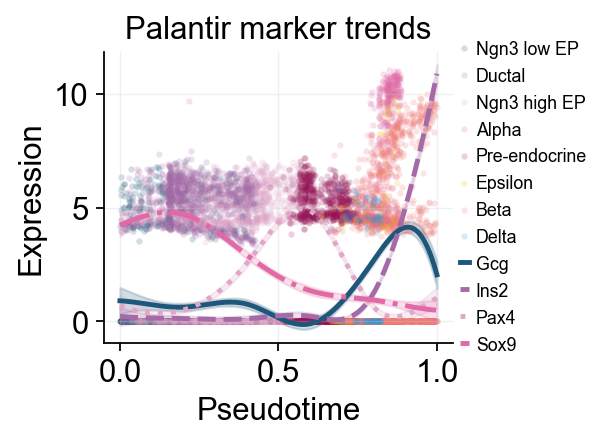

✅ Dynamic trend plotting completed!


In [20]:
palantir_compare_genes = ['Gcg', 'Ins2', 'Pax4', 'Sox9']

ov.pl.dynamic_trends(
    dyn_res,
    genes=palantir_compare_genes,
    compare_features=True,
    add_point=True,
    point_color_by='clusters',
    line_style_by='features',
    linewidth=2.2,
    figsize=(4.8, 3),
    legend_loc='right margin',
    legend_fontsize=8,
    title='Palantir marker trends',
)
plt.show()


🔍 Dynamic trend plotting:
   Features: 3 | Groups: 2
   compare_features=False | compare_groups=True


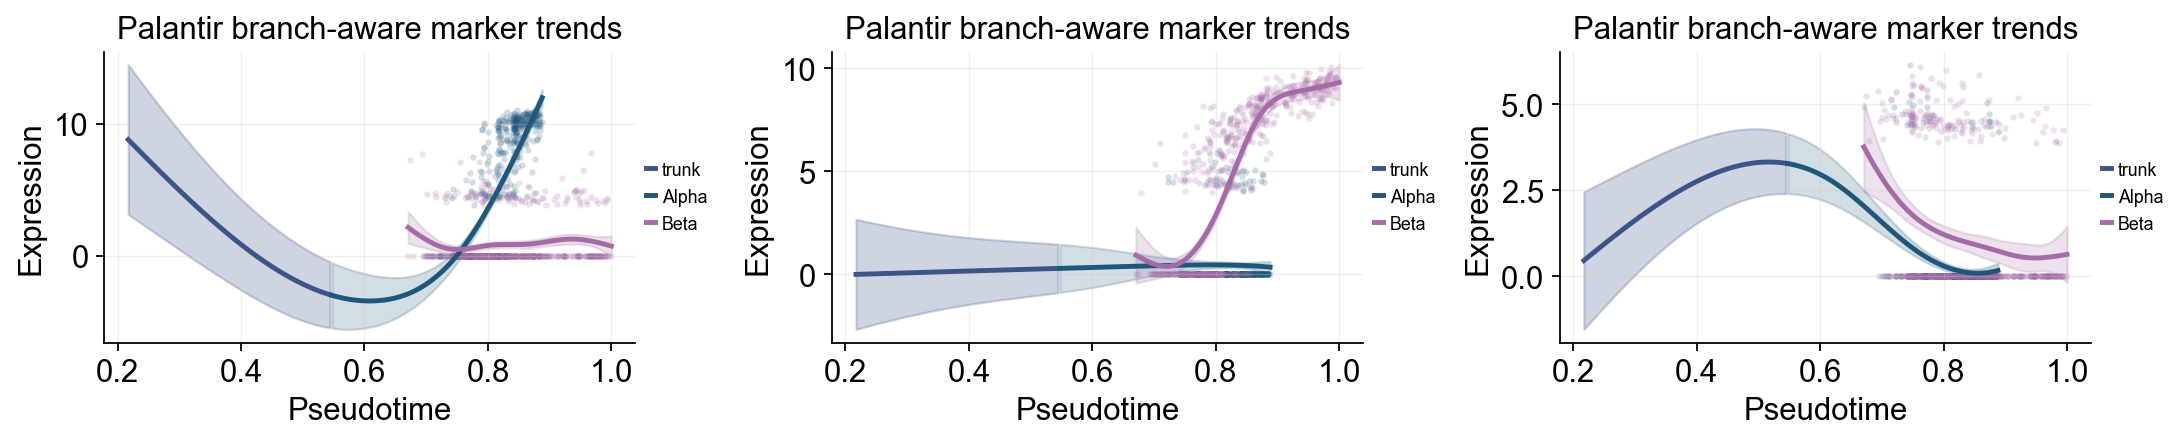

✅ Dynamic trend plotting completed!


In [21]:
palantir_split_mask = adata.obs['clusters'].astype(str).isin(['Ngn3 high EP', 'Pre-endocrine'])
palantir_split_time = float(np.nanmedian(adata.obs.loc[palantir_split_mask, 'palantir_pseudotime'])) if palantir_split_mask.any() else float(np.nanmedian(adata.obs['palantir_pseudotime']))

ov.pl.dynamic_trends(
    grouped_dyn_res,
    genes=['Gcg', 'Ins2', 'Pax4'],
    compare_groups=True,
    split_time=palantir_split_time,
    shared_trunk=True,
    add_point=True,
    point_color_by='group',
    figsize=(5.5, 3),
    linewidth=2.2,
    ncols=3,
    legend_loc='right margin',
    legend_fontsize=8,
    title='Palantir branch-aware marker trends',
)
plt.show()

## Summarize Palantir trends with a dynamic heatmap

After computing `palantir_pseudotime` and `MAGIC_imputed_data`, we can use `ov.pl.dynamic_heatmap` to summarize pancreas marker dynamics along pseudotime. Compared with the single-gene trend curves above, the dynamic heatmap makes it easier to compare the activation order of multiple lineage programs in one view.



🔍 Dynamic heatmap:
   Candidate features: 10
   Pseudotime: palantir_pseudotime
   Cell annotation: clusters
   use_fitted=True | cell_bins=200 | cmap=viridis



✅ Dynamic heatmap completed!
   ✓ Matrix shape: 10 features × 200 columns


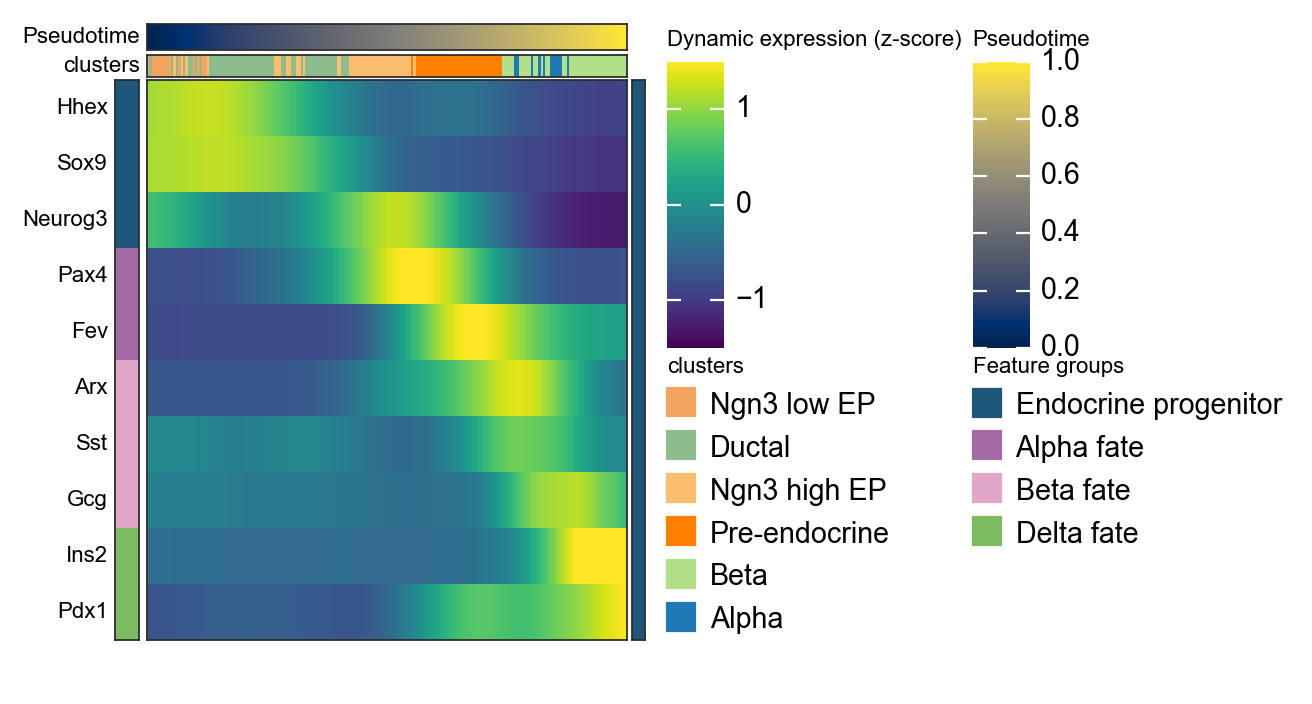

In [22]:
dynamic_marker_modules = {
    'Endocrine progenitor': ['Sox9', 'Neurog3', 'Fev'],
    'Alpha fate': ['Gcg', 'Arx'],
    'Beta fate': ['Pax4', 'Ins2', 'Pdx1'],
    'Delta fate': ['Sst', 'Hhex'],
}

d = ov.pl.dynamic_heatmap(
    adata,
    var_names=dynamic_marker_modules,
    pseudotime='palantir_pseudotime',
    layer='MAGIC_imputed_data',
    cell_annotation='clusters',
    # Bin columns are more stable here and preserve annotation tracks.
    use_cell_columns=False,
    cell_bins=200,
    smooth_window=21,
    fitted_window=41,
    figsize=(4, 5),
    standard_scale='var',
    cmap='viridis',
    show_row_names=True,
    border=True,
    show=False,
)

We can also use paga to visualize the cell stages

In [23]:
ov.utils.cal_paga(
    adata,
    use_time_prior='palantir_pseudotime',
    vkey='paga',
    groups='clusters'
)

running PAGA using priors: ['palantir_pseudotime']


    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


<Axes: title={'center': 'PAGA palantir-graph'}>

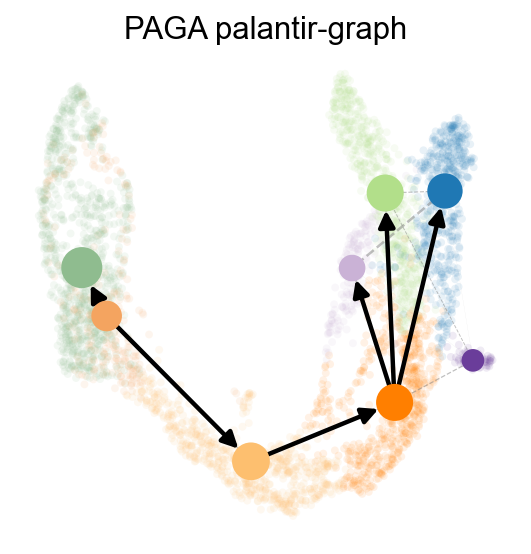

In [24]:
ov.utils.plot_paga(
    adata,basis='umap',
    size=50,
    alpha=.1,
    title='PAGA palantir-graph',
    min_edge_width=2,
    node_size_scale=1.5,
    show=False,
    legend_loc=False
)